In [1]:
import os 
os.chdir('../../')
os.environ["DPM_TQDM"] = "False"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

!nvidia-smi

Fri Aug 15 10:08:37 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:19:00.0 Off |                  Off |
| 88%   89C    P2            350W /  450W |   16717MiB /  24564MiB |     82%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from backbones.dit import DiT

# 사용 예
model = DiT()
print(model)

/home/scpark/miniconda3/envs/rbf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]An error occurred while trying to fetch /data/huggingface/DiT-XL-2-256/transformer: Error no file named diffusion_pytorch_model.safetensors found in directory /data/huggingface/DiT-XL-2-256/transformer.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  33%|███▎      | 1/3 [00:00<00:00,  2.03it/s]An error occurred while trying to fetch /data/huggingface/DiT-XL-2-256/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /data/huggingface/DiT-XL-2-256/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline co

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def display_class_images(pixel_samples, class_ids=None, figsize_per_image=1.5, display_title=""):
    samples = list(pixel_samples)
    processed = []
    for img in samples:
        if isinstance(img, Image.Image):
            arr = np.array(img)
        else:
            arr = np.array(img)
            if arr.ndim == 3 and arr.shape[0] in (1,3):
                arr = arr.transpose(1, 2, 0)
        processed.append(arr)

    n = len(processed)
    if class_ids is None:
        class_ids = list(range(n))

    fig, axes = plt.subplots(1, n, figsize=(n * figsize_per_image, figsize_per_image))
    if n == 1:
        axes = [axes]

    # 전체 제목 추가
    if display_title:
        fig.suptitle(display_title, fontsize=10, y=1.1)  # y 값을 1.02로 올려서 제목을 위로 이동
    # 플롯 레이아웃 조정: top을 낮춰서 제목과 플롯 사이에 공간 확보
    
    for ax, img_arr, lbl in zip(axes, processed, class_ids):
        ax.imshow(img_arr)
        ax.axis("off")
        ax.set_title(f"Class {lbl}", fontsize=8)

    plt.show()


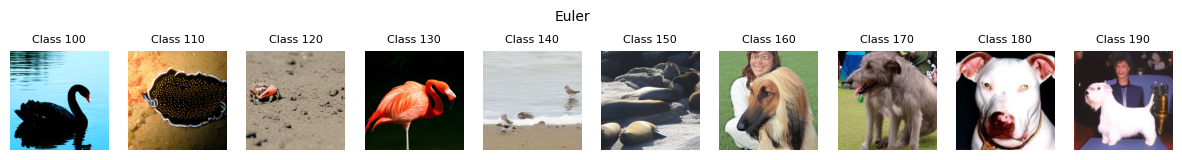

In [28]:
from solvers.others.dpm_solver import DPM_Solver
from solvers.others.euler_solver import Euler_Solver
from solvers.others.unipc_solver import UniPC_Solver

# 클래스 0–9로 설정
class_ids = [i for i in range(100, 200, 10)]
noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=class_ids, guidance_scale=3.0)
latents = model.get_noise(seeds=class_ids)

NFE = 20
solver = Euler_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
euler_latents = solver.sample(latents, model_fn)['samples']
euler_samples = model.decode_vae(euler_latents)
display_class_images(euler_samples, class_ids, display_title='Euler')



In [29]:
!ls "logs/CFG4.0/0815-6:CLIP,pred,table,quality" -l 
#!ls "logs/CFG4.0/0815-3:BNS,CLIP Training(Cosine)" -l

total 128
-rw-rw-r-- 1 scpark scpark     88  8월 15 10:06 events.out.tfevents.1755220005.scpark-X299-WU8.28712.0
-rw-rw-r-- 1 scpark scpark 106894  8월 15 10:16 events.out.tfevents.1755220011.scpark-X299-WU8.28712.1
-rw-rw-r-- 1 scpark scpark   2709  8월 15 10:09 step_00000100.pt
-rw-rw-r-- 1 scpark scpark   2709  8월 15 10:11 step_00000200.pt
-rw-rw-r-- 1 scpark scpark   2709  8월 15 10:14 step_00000300.pt


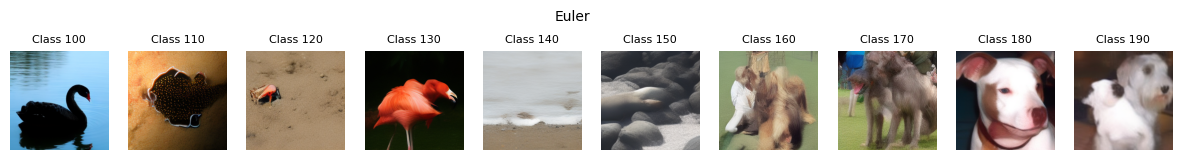

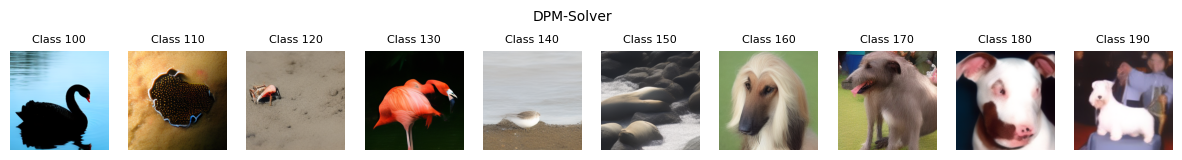

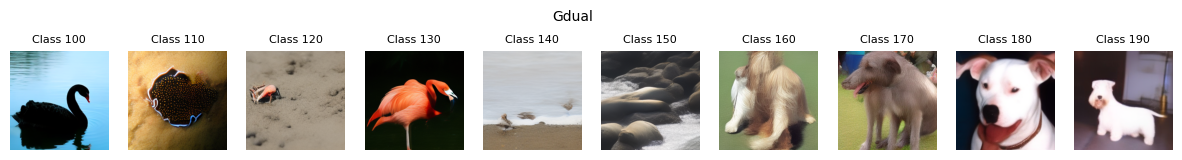

In [30]:
import numpy as np
import torch
import time

NFE = 5
solver = Euler_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
euler_latents = solver.sample(latents, model_fn)['samples']
euler_samples = model.decode_vae(euler_latents)
display_class_images(euler_samples, class_ids, display_title='Euler')

solver = DPM_Solver(noise_schedule, algorithm_type="data_prediction")
euler_latents = solver.sample(model_fn, latents, steps=NFE, skip_type='time_uniform')
euler_samples = model.decode_vae(euler_latents)
display_class_images(euler_samples, class_ids, display_title='DPM-Solver')

from solvers.dual.dynamic.gdual_solver_log_deltaL_only import GDual_Solver
from solvers.transforms.loglinear_transform_general import LogLinearTransform
from solvers.param_extractors.table_extractor import Extractor

noise_schedule = model.get_noise_schedule()
solver = GDual_Solver(
    noise_schedule, steps=5, transform=LogLinearTransform(gamma_push=True, gamma_max=3, kappa_max=3, kappa_disable=False),
    param_extractor=Extractor(), skip_type="time_uniform", order=2, use_corrector=False, time_learning=True, train_mode=True
).to(model.device)

pt_file = 'logs/CFG4.0/0815-6:CLIP,pred,table,quality/step_00000300.pt'
state_dict = torch.load(pt_file, map_location='cpu')['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)
with torch.no_grad():
    euler_latents = solver.sample(latents, model_fn)
    euler_samples = model.decode_vae(euler_latents)
display_class_images(euler_samples, class_ids, display_title='Gdual')

# from solvers.competing.bns.bns_solver import BNS_Solver
# noise_schedule = model.get_noise_schedule()
# with torch.no_grad():
#     solver = BNS_Solver(
#             noise_schedule,
#             steps=5,
#             skip_type="time_uniform",
#         ).to(model.device)

#     pt_file = 'logs/CFG4.0/0815-3:BNS,CLIP Training(Cosine)/step_00001300.pt'
#     state_dict = torch.load(pt_file, map_location='cpu')['solver_state_dict']
#     solver.load_state_dict(state_dict, strict=True)

#     euler_latents = solver.sample(latents, model_fn)
#     euler_samples = model.decode_vae(euler_latents)
# display_class_images(euler_samples, class_ids, display_title='BNS')

